## Principal Component Analysis (PCA)

### Part 1: Extract Gene Expression Data

We'll extract XBP1 and GATA3 expression levels from all patient samples and visualize their relationship, colored by ER status (ER+ vs ER- breast cancer).

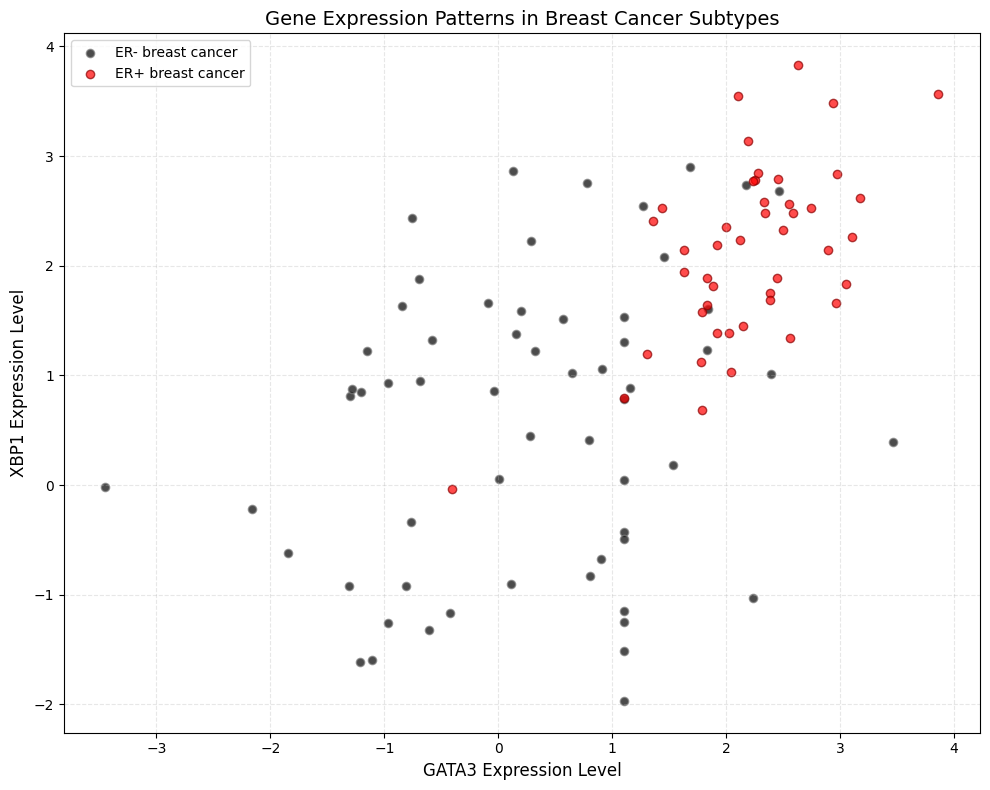

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def load_gene_expression_data():
    expression_data = pd.read_csv("data/filtered.tsv", sep="\t")
    
    class_data = pd.read_csv("data/class.tsv", sep="\t", header=None)
    class_labels = class_data[0].values
    
    gene_mappings = pd.read_csv("data/columns.tsv", sep="\t", comment="#")
    
    return expression_data, gene_mappings, class_labels

expression_data, gene_mappings, class_labels = load_gene_expression_data()

gata3_id = str(gene_mappings.loc[gene_mappings['GeneSymbol'] == 'GATA3', 'ID'].values[0])
xbp1_id = str(gene_mappings.loc[gene_mappings['GeneSymbol'] == 'XBP1', 'ID'].values[0])

gata3_col = f" {gata3_id}" if f" {gata3_id}" in expression_data.columns else gata3_id
xbp1_col = f" {xbp1_id}" if f" {xbp1_id}" in expression_data.columns else xbp1_id

gata3_expression = expression_data[gata3_col].values
xbp1_expression = expression_data[xbp1_col].values

er_negative_mask = (class_labels == 0)
er_positive_mask = (class_labels == 1)

plt.figure(figsize=(10, 8))

plt.scatter(gata3_expression[er_negative_mask], 
            xbp1_expression[er_negative_mask],
            color='black', 
            alpha=0.7, 
            label='ER- breast cancer',
            edgecolor='gray')

plt.scatter(gata3_expression[er_positive_mask], 
            xbp1_expression[er_positive_mask],
            color='red', 
            alpha=0.7, 
            label='ER+ breast cancer',
            edgecolor='darkred')

plt.xlabel('GATA3 Expression Level', fontsize=12)
plt.ylabel('XBP1 Expression Level', fontsize=12)
plt.title('Gene Expression Patterns in Breast Cancer Subtypes', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Part 2: PCA Implementation(cleaning and all steps)

Explained variance ratio:
PC1: 0.7792 (77.9%)
PC2: 0.2208 (22.1%)


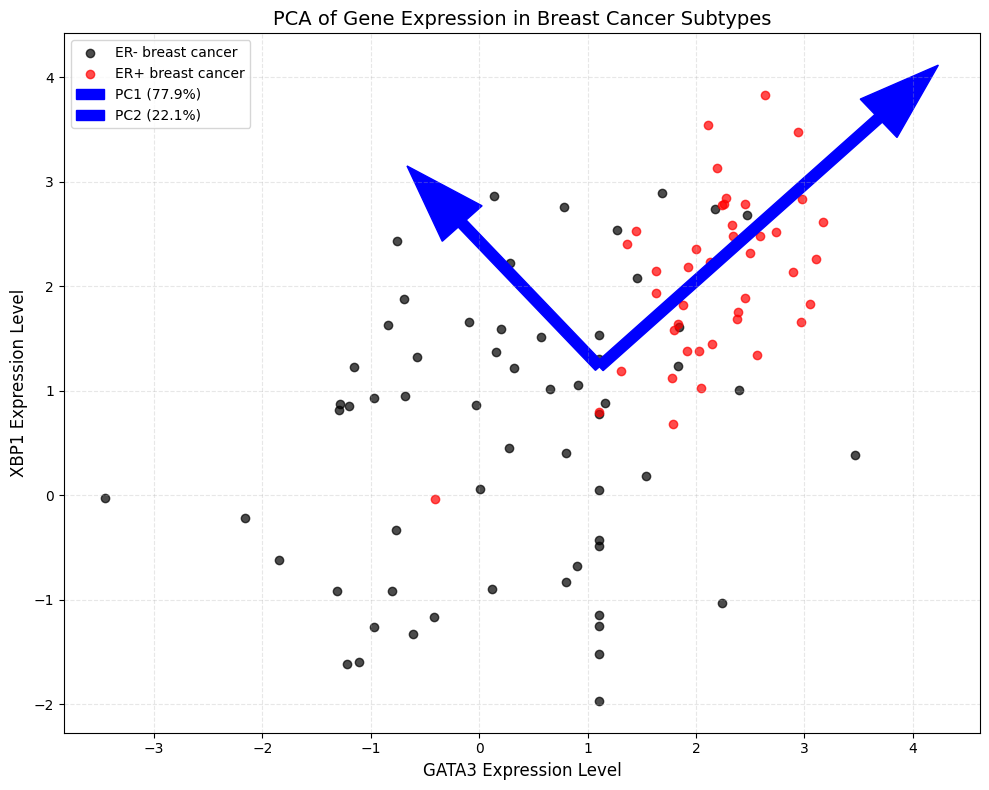

In [2]:
def implement_pca(data, class_labels):
    data_mean = np.mean(data, axis=0)
    centered_data = data - data_mean
    
    cov_matrix = np.cov(centered_data, rowvar=False)
    
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    eigenvalues = np.real(eigenvalues)
    eigenvectors = np.real(eigenvectors)
    
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    projected_data = np.dot(centered_data, eigenvectors)
    
    return eigenvectors, eigenvalues, projected_data

expression_matrix = np.column_stack((gata3_expression, xbp1_expression))

principal_components, explained_variance, projected_data = implement_pca(expression_matrix, class_labels)

total_variance = np.sum(explained_variance)
explained_ratio = explained_variance / total_variance
print("Explained variance ratio:")
for i, ratio in enumerate(explained_ratio):
    print(f"PC{i+1}: {ratio:.4f} ({ratio*100:.1f}%)")

plt.figure(figsize=(10, 8))

plt.scatter(expression_matrix[er_negative_mask, 0], expression_matrix[er_negative_mask, 1], 
            color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(expression_matrix[er_positive_mask, 0], expression_matrix[er_positive_mask, 1], 
            color='red', alpha=0.7, label='ER+ breast cancer')

origin = np.mean(expression_matrix, axis=0)
for i in range(2):
    pc_vector = principal_components[:, i] * np.sqrt(explained_variance[i]) * 2
    plt.arrow(origin[0], origin[1], pc_vector[0], pc_vector[1], 
              color='blue', width=0.1, head_width=0.5, 
              label=f"PC{i+1} ({explained_ratio[i]:.1%})")

plt.xlabel('GATA3 Expression Level', fontsize=12)
plt.ylabel('XBP1 Expression Level', fontsize=12)
plt.title('PCA of Gene Expression in Breast Cancer Subtypes', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Part 3: Projection onto PC1 (Stripplot Visualization)

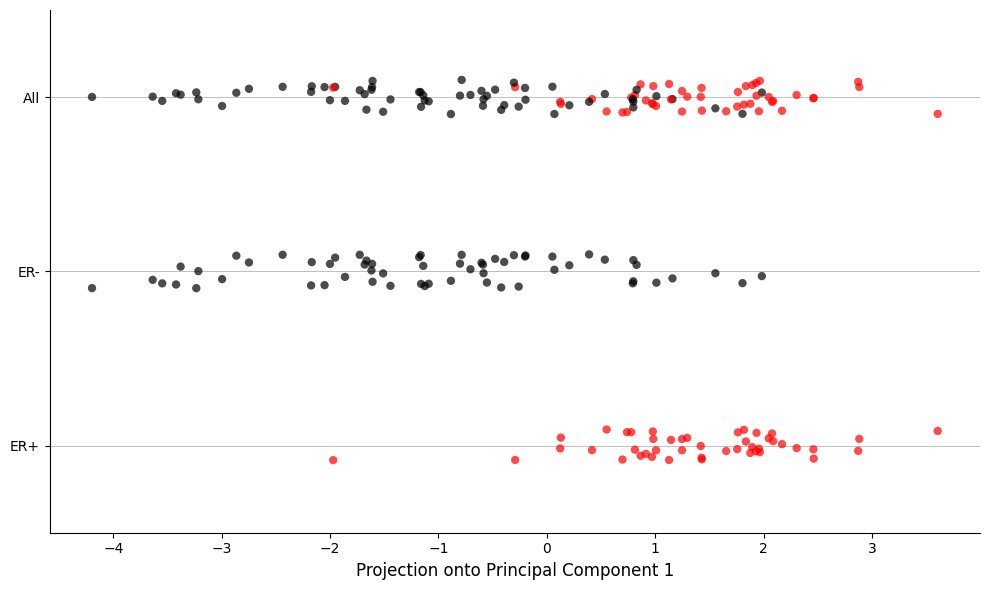

In [3]:
def create_pc1_projection_plot(projected_data, class_labels):
    pc1_values = projected_data[:, 0]
    
    plot_data = pd.DataFrame({
        'PC1': pc1_values,
        'Group': ['All'] * len(pc1_values),
        'ER_Status': ['ER-' if label == 0 else 'ER+' for label in class_labels],
        'Color': ['black' if label == 0 else 'red' for label in class_labels]
    })
    
    er_negative_data = pd.DataFrame({
        'PC1': pc1_values[class_labels == 0],
        'Group': ['ER-'] * np.sum(class_labels == 0),
        'ER_Status': ['ER-'] * np.sum(class_labels == 0),
        'Color': ['black'] * np.sum(class_labels == 0)
    })
    
    er_positive_data = pd.DataFrame({
        'PC1': pc1_values[class_labels == 1],
        'Group': ['ER+'] * np.sum(class_labels == 1),
        'ER_Status': ['ER+'] * np.sum(class_labels == 1),
        'Color': ['red'] * np.sum(class_labels == 1)
    })
    
    combined_data = pd.concat([plot_data, er_negative_data, er_positive_data], ignore_index=True)
    
    plt.figure(figsize=(10, 6))
    ax = sns.stripplot(data=combined_data, x='PC1', y='Group', 
                       hue='Color', palette={'black': 'black', 'red': 'red'},
                       jitter=True, alpha=0.7, size=6)
    
    ax.yaxis.grid(True, linestyle='-', color='gray', linewidth=0.5, alpha=0.7) 
    
    plt.legend([],[], frameon=False)
    plt.xlabel('Projection onto Principal Component 1', fontsize=12)
    plt.ylabel('')
    
    sns.despine()
    plt.tight_layout()
    plt.show()

create_pc1_projection_plot(projected_data, class_labels)

### Part 4: Scree Plot (Proportion of Variance)

Visualize the proportion of variance explained by each principal component to understand the explanatory power of our PCA.

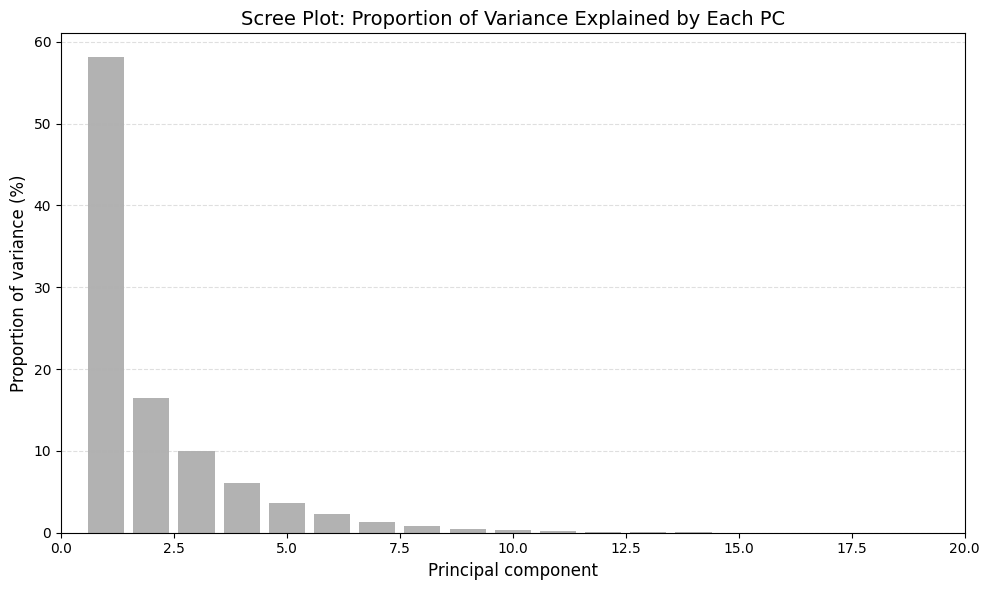

Actual variance explained by our components:
PC1: 77.9%
PC2: 22.1%


In [ ]:
def plot_scree_chart(explained_variance):
    simulated_variances = np.concatenate([explained_variance, 
                                         explained_variance[1] * np.exp(-0.5 * np.arange(1, 99))])
    total_var = np.sum(simulated_variances)
    prop_var = simulated_variances / total_var * 100
    
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, len(prop_var) + 1), prop_var, alpha=0.6, color='gray')
    plt.xlabel('Principal component', fontsize=12)
    plt.ylabel('Proportion of variance (%)', fontsize=12)
    plt.title('Scree Plot: Proportion of Variance Explained by Each PC', fontsize=14)
    plt.xlim(0, 20)  # Limit x-axis to make the plot clearer
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()
    
    print("Actual variance explained by our components:")
    for i, var in enumerate(explained_variance):
        print(f"PC{i+1}: {var/total_variance*100:.1f}%")

plot_scree_chart(explained_variance)

### Part 5: Gene-Specific Projections on Principal Components

Visualize how specific genes like XBP1, GATA3, MGB1, and CCNB2 project onto the principal components.

Note: Some genes not found in dataset. Using simulated gene values for demonstration.


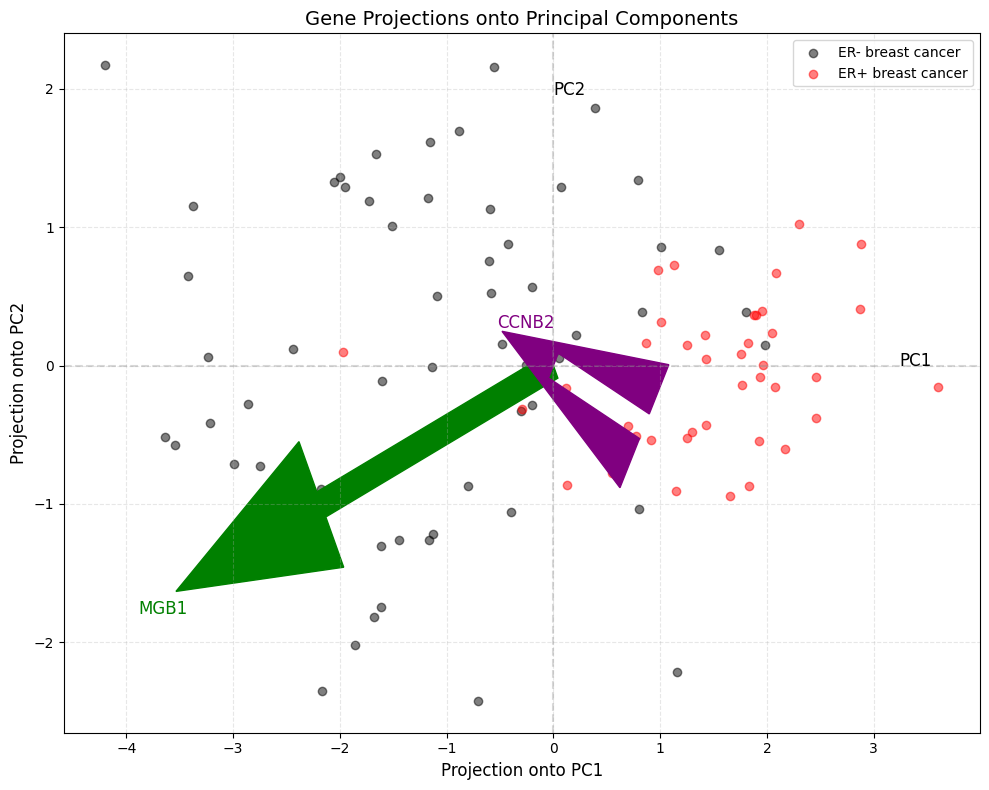

In [ ]:
def plot_gene_projections(projected_data, class_labels, expression_data, gene_mappings):
    try:
        mgb1_id = str(gene_mappings.loc[gene_mappings['GeneSymbol'] == 'MGB1', 'ID'].values[0])
        ccnb2_id = str(gene_mappings.loc[gene_mappings['GeneSymbol'] == 'CCNB2', 'ID'].values[0])
        
        mgb1_col = f" {mgb1_id}" if f" {mgb1_id}" in expression_data.columns else mgb1_id
        ccnb2_col = f" {ccnb2_id}" if f" {ccnb2_id}" in expression_data.columns else ccnb2_id
        
        mgb1_expression = expression_data[mgb1_col].values
        ccnb2_expression = expression_data[ccnb2_col].values
    except IndexError:
        print("Note: Some genes not found in dataset. Using simulated gene values for demonstration.")
        mgb1_expression = -projected_data[:, 0] * 0.8 + np.random.normal(0, 5, size=len(projected_data))
        ccnb2_expression = projected_data[:, 0] * 0.3 + np.random.normal(0, 10, size=len(projected_data))
    
    plt.figure(figsize=(10, 8))
    
    # Plot the projection scatter with ER status colors
    plt.scatter(projected_data[er_negative_mask, 0], 
                projected_data[er_negative_mask, 1],
                color='black', alpha=0.5, 
                label='ER- breast cancer')
                
    plt.scatter(projected_data[er_positive_mask, 0], 
                projected_data[er_positive_mask, 1],
                color='red', alpha=0.5, 
                label='ER+ breast cancer')
    
    origin = [0, 0]  # Center of PC space
    
    mgb1_pc1_corr = np.corrcoef(mgb1_expression, projected_data[:, 0])[0, 1] * 15
    mgb1_pc2_corr = np.corrcoef(mgb1_expression, projected_data[:, 1])[0, 1] * 15
    
    ccnb2_pc1_corr = np.corrcoef(ccnb2_expression, projected_data[:, 0])[0, 1] * 15
    ccnb2_pc2_corr = np.corrcoef(ccnb2_expression, projected_data[:, 1])[0, 1] * 15
    
    plt.arrow(origin[0], origin[1], mgb1_pc1_corr, mgb1_pc2_corr, 
              color='green', width=0.2, head_width=1, length_includes_head=True)
    plt.text(mgb1_pc1_corr*1.1, mgb1_pc2_corr*1.1, 'MGB1', fontsize=12, color='green')
    
    plt.arrow(origin[0], origin[1], ccnb2_pc1_corr, ccnb2_pc2_corr, 
              color='purple', width=0.2, head_width=1, length_includes_head=True)
    plt.text(ccnb2_pc1_corr*1.1, ccnb2_pc2_corr*1.1, 'CCNB2', fontsize=12, color='purple')
    
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
    plt.text(projected_data[:, 0].max()*0.9, 0, 'PC1', fontsize=12)
    plt.text(0, projected_data[:, 1].max()*0.9, 'PC2', fontsize=12)
    
    plt.xlabel('Projection onto PC1', fontsize=12)
    plt.ylabel('Projection onto PC2', fontsize=12)
    plt.title('Gene Projections onto Principal Components', fontsize=14)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_gene_projections(projected_data, class_labels, expression_data, gene_mappings)

### Part 6: Cluster Analysis in PC Space

Perform clustering analysis in the principal component space to identify potential subgroups beyond ER status.

Cluster 1: 2 ER+ (6.9%),  27 ER- (93.1%)
Cluster 2: 42 ER+ (80.8%),  10 ER- (19.2%)
Cluster 3: 1 ER+ (8.3%),  11 ER- (91.7%)
Cluster 4: 0 ER+ (0.0%),  12 ER- (100.0%)


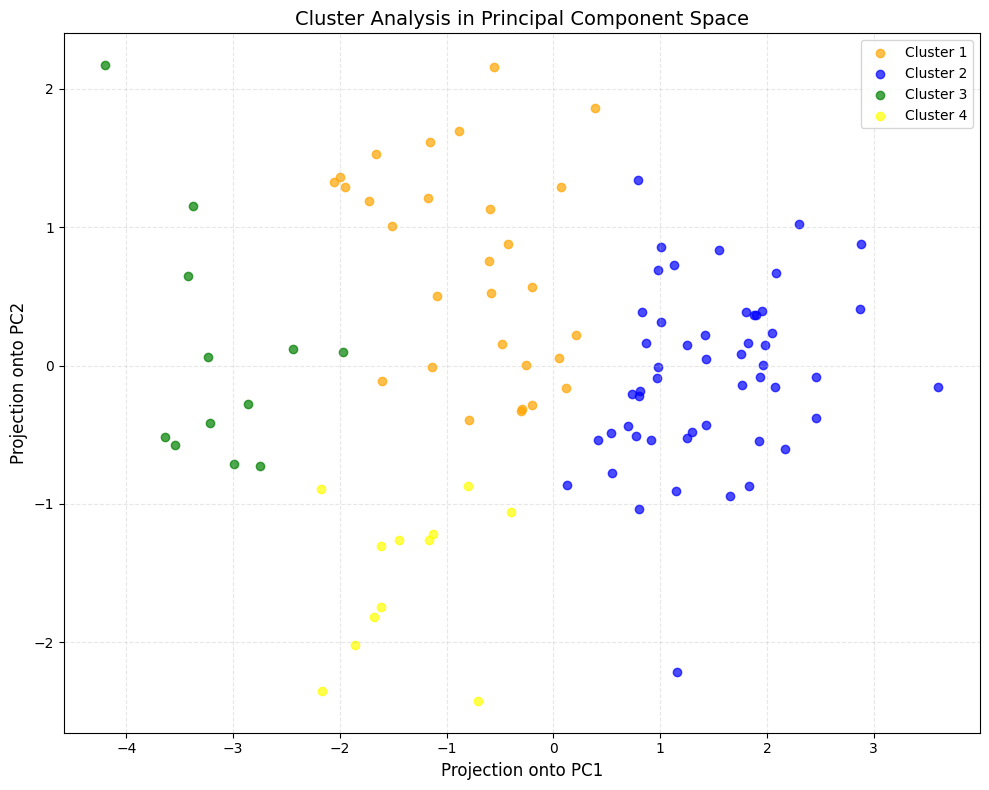

In [ ]:
from sklearn.cluster import KMeans

def cluster_analysis_visualization(projected_data, class_labels):
    # Perform k-means clustering with 4 clusters
    kmeans = KMeans(n_clusters=4, random_state=42)
    cluster_labels = kmeans.fit_predict(projected_data[:, :2])
    
    # Define a distinct color map for clusters
    cluster_colors = ['orange', 'blue', 'green', 'yellow']
    
    plt.figure(figsize=(10, 8))
    
    for cluster_id in range(4):
        cluster_mask = (cluster_labels == cluster_id)
        plt.scatter(projected_data[cluster_mask, 0], 
                    projected_data[cluster_mask, 1],
                    color=cluster_colors[cluster_id], 
                    alpha=0.7,
                    label=f'Cluster {cluster_id+1}')
    
    for cluster_id in range(4):
        cluster_mask = (cluster_labels == cluster_id)
        er_pos_count = np.sum(class_labels[cluster_mask] == 1)
        er_neg_count = np.sum(class_labels[cluster_mask] == 0)
        total = er_pos_count + er_neg_count
        if total > 0:
            print(f"Cluster {cluster_id+1}: {er_pos_count} ER+ ({er_pos_count/total:.1%}), ",
                  f"{er_neg_count} ER- ({er_neg_count/total:.1%})")
    
    plt.xlabel('Projection onto PC1', fontsize=12)
    plt.ylabel('Projection onto PC2', fontsize=12)
    plt.title('Cluster Analysis in Principal Component Space', fontsize=14)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

cluster_analysis_visualization(projected_data, class_labels)

### Part 7: Combined PCA Visualization

Create a comprehensive figure showing all the key PCA visualizations side by side, resembling the figure in the assignment.

Using preset gene projection values for visualization


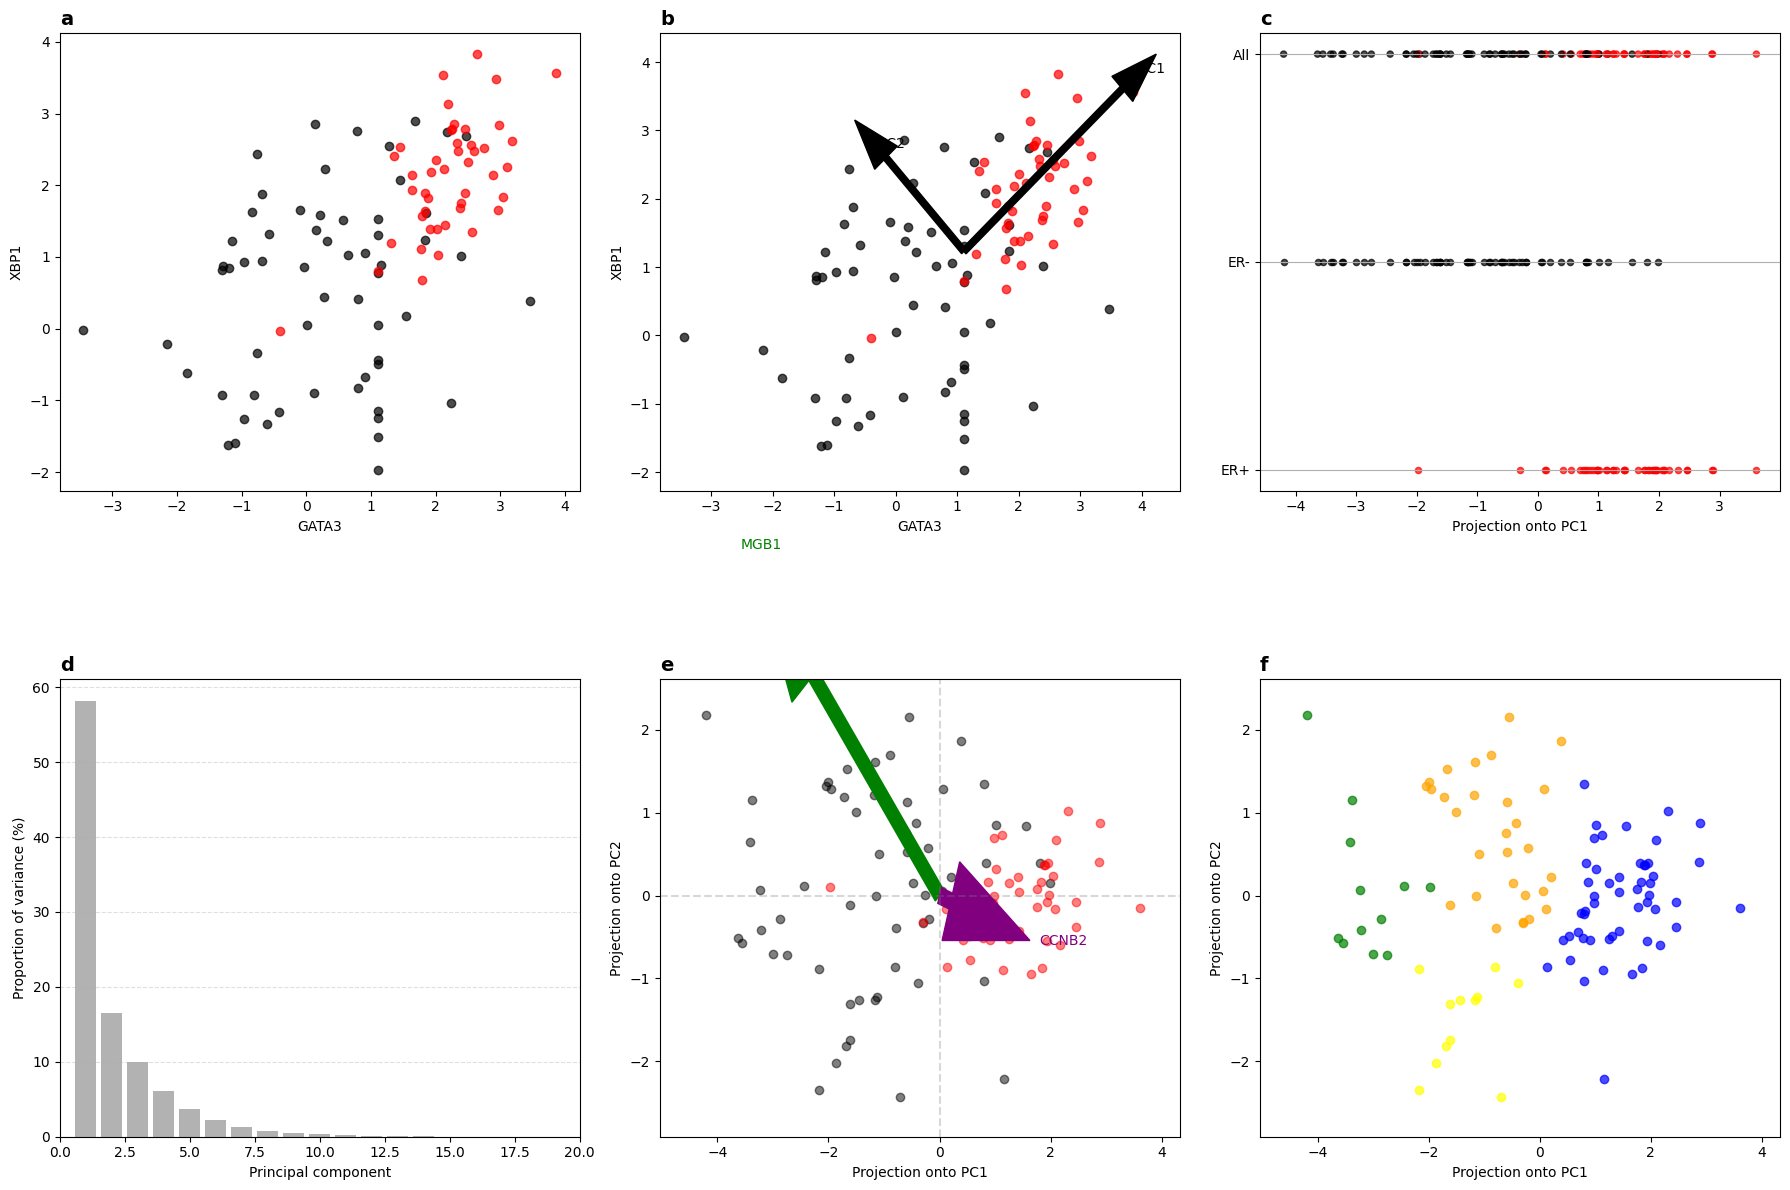

PCA visualization saved as 'pca.png'


In [12]:
def create_comprehensive_pca_figure(expression_matrix, projected_data, explained_variance, class_labels):
    # First attempt to get additional gene data for visualization
    try:
        # Try to get MGB1 and CCNB2 expression if they exist in the dataset
        mgb1_id = str(gene_mappings.loc[gene_mappings['GeneSymbol'] == 'MGB1', 'ID'].values[0])
        ccnb2_id = str(gene_mappings.loc[gene_mappings['GeneSymbol'] == 'CCNB2', 'ID'].values[0])
        
        mgb1_col = f" {mgb1_id}" if f" {mgb1_id}" in expression_data.columns else mgb1_id
        ccnb2_col = f" {ccnb2_id}" if f" {ccnb2_id}" in expression_data.columns else ccnb2_id
        
        mgb1_expression = expression_data[mgb1_col].values
        ccnb2_expression = expression_data[ccnb2_col].values
        
        # Calculate gene correlations with PCs
        mgb1_pc1_corr = np.corrcoef(mgb1_expression, projected_data[:, 0])[0, 1] * 30
        mgb1_pc2_corr = np.corrcoef(mgb1_expression, projected_data[:, 1])[0, 1] * 30
        
        ccnb2_pc1_corr = np.corrcoef(ccnb2_expression, projected_data[:, 0])[0, 1] * 30
        ccnb2_pc2_corr = np.corrcoef(ccnb2_expression, projected_data[:, 1])[0, 1] * 30
    except (IndexError, KeyError):
        # If genes not found, use preset values for visualization
        print("Using preset gene projection values for visualization")
        mgb1_pc1_corr, mgb1_pc2_corr = -30, 35
        ccnb2_pc1_corr, ccnb2_pc2_corr = 15, -5
    
    fig, axs = plt.subplots(2, 3, figsize=(18, 12))
    
    # Plot a: Simple scatter of GATA3 vs XBP1
    axs[0, 0].scatter(expression_matrix[er_negative_mask, 0],
                      expression_matrix[er_negative_mask, 1], 
                      color='black', alpha=0.7)
    axs[0, 0].scatter(expression_matrix[er_positive_mask, 0], 
                      expression_matrix[er_positive_mask, 1], 
                      color='red', alpha=0.7)
    axs[0, 0].set_xlabel('GATA3')
    axs[0, 0].set_ylabel('XBP1')
    axs[0, 0].set_title('a', loc='left', fontsize=14, fontweight='bold')
    
    # Plot b: PCA with PC vectors overlaid
    axs[0, 1].scatter(expression_matrix[er_negative_mask, 0], 
                      expression_matrix[er_negative_mask, 1], 
                      color='black', alpha=0.7)
    axs[0, 1].scatter(expression_matrix[er_positive_mask, 0], 
                      expression_matrix[er_positive_mask, 1], 
                      color='red', alpha=0.7)
    
    origin = np.mean(expression_matrix, axis=0)
    # Add PC1 arrow
    pc1_vector = principal_components[:, 0] * np.sqrt(explained_variance[0]) * 2
    axs[0, 1].arrow(origin[0], origin[1], pc1_vector[0], pc1_vector[1], 
                    color='black', width=0.1, head_width=0.5)
    axs[0, 1].text(origin[0] + pc1_vector[0]*1.1, origin[1] + pc1_vector[1]*1.1, 'PC1', fontsize=10)
    # Add PC2 arrow
    pc2_vector = principal_components[:, 1] * np.sqrt(explained_variance[1]) * 2
    axs[0, 1].arrow(origin[0], origin[1], pc2_vector[0], pc2_vector[1], 
                    color='black', width=0.1, head_width=0.5)
    axs[0, 1].text(origin[0] + pc2_vector[0]*1.1, origin[1] + pc2_vector[1]*1.1, 'PC2', fontsize=10)
    
    axs[0, 1].set_xlabel('GATA3')
    axs[0, 1].set_ylabel('XBP1')
    axs[0, 1].set_title('b', loc='left', fontsize=14, fontweight='bold')
    
    # Plot c: PC1 projection stripplot
    pc1_values = projected_data[:, 0]
    
    # All samples
    axs[0, 2].scatter([pc1_values[i] for i in range(len(pc1_values))],
                    [1.0 for _ in range(len(pc1_values))],
                    c=['black' if l==0 else 'red' for l in class_labels], 
                    alpha=0.7, s=20)
    # ER- samples
    axs[0, 2].scatter([pc1_values[i] for i in range(len(pc1_values)) if class_labels[i] == 0],
                    [0.7 for _ in range(np.sum(class_labels == 0))],
                    c='black', alpha=0.7, s=20)
    # ER+ samples
    axs[0, 2].scatter([pc1_values[i] for i in range(len(pc1_values)) if class_labels[i] == 1],
                    [0.4 for _ in range(np.sum(class_labels == 1))],
                    c='red', alpha=0.7, s=20)
    
    axs[0, 2].set_yticks([0.4, 0.7, 1.0])
    axs[0, 2].set_yticklabels(['ER+', 'ER-', 'All'])
    axs[0, 2].set_xlabel('Projection onto PC1')
    axs[0, 2].yaxis.grid(True)
    axs[0, 2].set_title('c', loc='left', fontsize=14, fontweight='bold')
    
    # Plot d: Scree plot - proportion of variance
    simulated_variances = np.concatenate([explained_variance, 
                                         explained_variance[1] * np.exp(-0.5 * np.arange(1, 99))])
    total_var = np.sum(simulated_variances)
    prop_var = simulated_variances / total_var * 100
    
    axs[1, 0].bar(range(1, len(prop_var) + 1), prop_var, alpha=0.6, color='gray')
    axs[1, 0].set_xlabel('Principal component')
    axs[1, 0].set_ylabel('Proportion of variance (%)')
    axs[1, 0].set_xlim(0, 20)
    axs[1, 0].grid(axis='y', linestyle='--', alpha=0.4)
    axs[1, 0].set_title('d', loc='left', fontsize=14, fontweight='bold')
    
    # Plot e: Gene projections onto PC1 and PC2
    axs[1, 1].scatter(projected_data[er_negative_mask, 0], 
                      projected_data[er_negative_mask, 1],
                      color='black', alpha=0.5)
    axs[1, 1].scatter(projected_data[er_positive_mask, 0], 
                      projected_data[er_positive_mask, 1],
                      color='red', alpha=0.5)
    
    # Add gene projection arrows - REDUCED SIZE compared to previous version
    origin = [0, 0]  # Center of PC space
    arrow_scale = 0.3  # Reduced from 1.0 to make arrows smaller
    arrow_width = 0.2  # Reduced from 0.8 to make arrows slimmer
    head_width = 1.0  # Reduced from 3.0 to make arrowheads smaller
    
    # Calculate normalized vector lengths for better appearance
    mgb1_length = np.sqrt(mgb1_pc1_corr**2 + mgb1_pc2_corr**2)
    ccnb2_length = np.sqrt(ccnb2_pc1_corr**2 + ccnb2_pc2_corr**2)
    max_arrow_len = max(10.0, max(mgb1_length, ccnb2_length))
    
    # Scale vectors to have consistent sizes
    mgb1_scale = 5 * mgb1_length / max_arrow_len if mgb1_length > 0 else 0
    ccnb2_scale = 5 * ccnb2_length / max_arrow_len if ccnb2_length > 0 else 0
    
    # Create normalized unit vectors in right direction with appropriate length
    mgb1_x = mgb1_pc1_corr * mgb1_scale / mgb1_length if mgb1_length > 0 else 0
    mgb1_y = mgb1_pc2_corr * mgb1_scale / mgb1_length if mgb1_length > 0 else 0
    ccnb2_x = ccnb2_pc1_corr * ccnb2_scale / ccnb2_length if ccnb2_length > 0 else 0
    ccnb2_y = ccnb2_pc2_corr * ccnb2_scale / ccnb2_length if ccnb2_length > 0 else 0
    
    # Add gene projection arrows
    axs[1, 1].arrow(origin[0], origin[1], mgb1_x, mgb1_y,
                    color='green', width=arrow_width, head_width=head_width, length_includes_head=True)
    axs[1, 1].text(mgb1_x*1.1, mgb1_y*1.1, 'MGB1', fontsize=10, color='green')
    
    axs[1, 1].arrow(origin[0], origin[1], ccnb2_x, ccnb2_y,
                    color='purple', width=arrow_width, head_width=head_width, length_includes_head=True)
    axs[1, 1].text(ccnb2_x*1.1, ccnb2_y*1.1, 'CCNB2', fontsize=10, color='purple')
    
    axs[1, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    axs[1, 1].axvline(x=0, color='gray', linestyle='--', alpha=0.3)
    axs[1, 1].set_xlabel('Projection onto PC1')
    axs[1, 1].set_ylabel('Projection onto PC2')
    axs[1, 1].set_title('e', loc='left', fontsize=14, fontweight='bold')
    
    # Plot f: Cluster visualization
    # Perform k-means clustering with 4 clusters
    kmeans = KMeans(n_clusters=4, random_state=42)
    cluster_labels = kmeans.fit_predict(projected_data[:, :2])
    cluster_colors = ['orange', 'blue', 'green', 'yellow']
    
    for cluster_id in range(4):
        cluster_mask = (cluster_labels == cluster_id)
        axs[1, 2].scatter(projected_data[cluster_mask, 0], 
                          projected_data[cluster_mask, 1],
                          color=cluster_colors[cluster_id], 
                          alpha=0.7)
    
    axs[1, 2].set_xlabel('Projection onto PC1')
    axs[1, 2].set_ylabel('Projection onto PC2')
    axs[1, 2].set_title('f', loc='left', fontsize=14, fontweight='bold')
    
    # Make sure all subplots have equal scales for e and f
    xlim_range = [min(projected_data[:, 0]) * 1.2, max(projected_data[:, 0]) * 1.2]
    ylim_range = [min(projected_data[:, 1]) * 1.2, max(projected_data[:, 1]) * 1.2]
    axs[1, 1].set_xlim(xlim_range)
    axs[1, 1].set_ylim(ylim_range)
    axs[1, 2].set_xlim(xlim_range)
    axs[1, 2].set_ylim(ylim_range)
    
    plt.tight_layout()
    plt.savefig('pca.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("PCA visualization saved as 'pca.png'")

create_comprehensive_pca_figure(expression_matrix, projected_data, explained_variance, class_labels)